# Data Cleaning and Visualization: 2008 Olympics Medalists

## Project Objective
The goal of this notebook is to clean the `olympics_08_medalists.csv` dataset by applying Tidy Data Principles. 
1. Each variable is in its own column.
2. Each observation forms its own row.
3. Each type of observational unit forms its own table.

We will use functions referenced in the [Pandas Cheat Sheet], such as `pd.melt()` and `pivot_table()`, to reshape the data from a wide, untidy format into a long, tidy format for exploratory data analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Load the dataset
df = pd.read_csv('olympics_08_medalists.csv')

# 2. Melt
df_melted = pd.melt(
    df,
    id_vars=["medalist_name"],
    var_name="Gender_Sport",
    value_name="Medal"
)

# drop missing medals
df_melted = df_melted.dropna()

# 3. Split Gender and Sport
df_melted["Gender"] = df_melted["Gender_Sport"].str.split("_").str[0]
df_melted["Sport"] = df_melted["Gender_Sport"].str.split("_").str[1]

df_melted["Sport"] = df_melted["Sport"].str.replace("_", " ")

df_tidy = df_melted.rename(columns={
    "medalist_name": "Medalist"
})

df_tidy = df_tidy[["Medalist", "Gender", "Sport", "Medal"]]

print("Tidy Data")
print(df_tidy.head())

Tidy Data
           Medalist Gender    Sport   Medal
177    Bair Badënov   male  archery  bronze
676   Ilario Di Buò   male  archery  silver
682    Im Dong-hyun   male  archery    gold
760       Jiang Lin   male  archery  bronze
920  Lee Chang-hwan   male  archery    gold


## Exploratory Data Analysis: Pivot Table
The data is tidy, so we can easily aggregate it. We will use a pivot table to count the number of Gold, Silver, and Bronze medals awarded per Sport.

In [15]:
# 3. Pivot Table: Medal Counts
# ---------------------------------------------------------
pivot_medals = pd.pivot_table(
    df_tidy,
    values="Medalist",
    index="Sport",
    columns="Medal",
    aggfunc="count",
    fill_value=0
)

pivot_medals["Total"] = pivot_medals.sum(axis=1)

pivot_medals = pivot_medals.sort_values(
    by="Total",
    ascending=False
)

print("\nPivot Table")
print(pivot_medals.head(10))



Pivot Table
Medal                  bronze  gold  silver  Total
Sport                                             
athletics                  55    52      59    166
rowing                     45    48      48    141
swimming                   43    39      43    125
association football       36    37      36    109
field hockey               33    33      32     98
handball                   28    29      28     85
water polo                 26    26      26     78
canoeing and kayaking      27    24      23     74
baseball                   24    24      24     72
volleyball                 24    24      24     72


## Visualizations
1. **Top 10 Sports by Total Medals**: Shows which events had the most medalists.
2. **Medal Distribution by Gender**: Compares the count of male vs. female medalists.

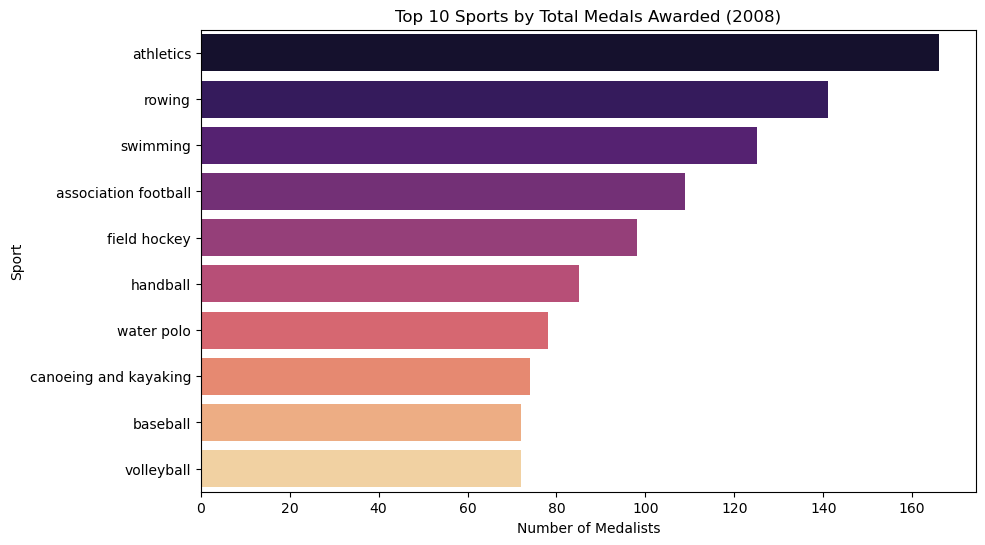

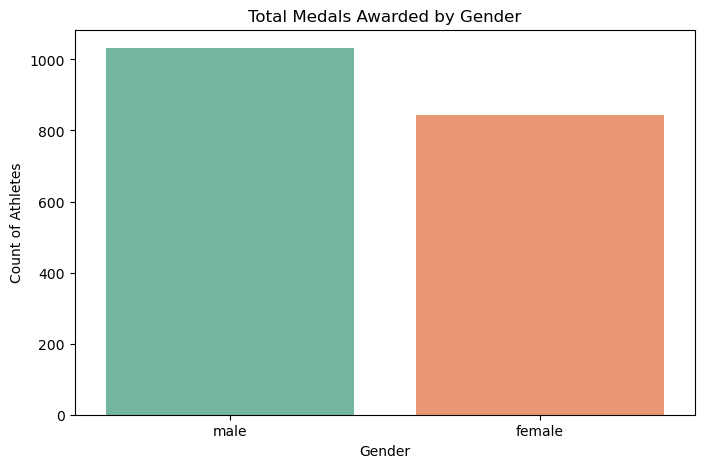

<Figure size 1200x600 with 0 Axes>

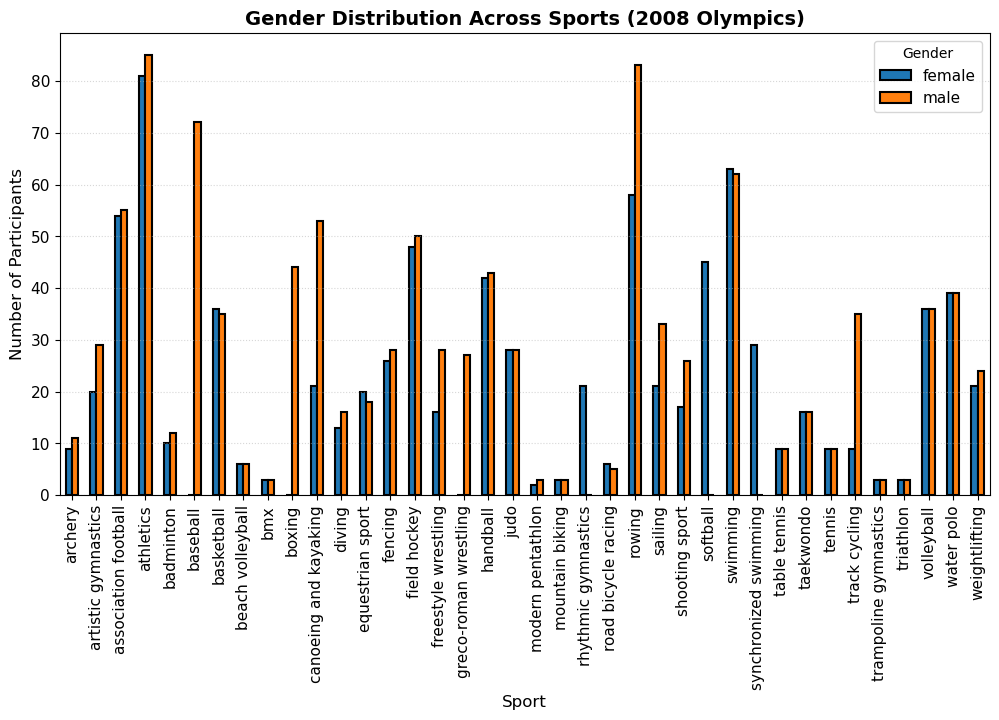

In [16]:
# Visualization 1: Top 10 Sports by Medal Volume
plt.figure(figsize=(10, 6))
top_sports = df_tidy['Sport'].value_counts().head(10)

sns.barplot(
    x=top_sports.values,
    y=top_sports.index,
    hue=top_sports.index,
    palette='magma',
    legend=False
)

plt.title('Top 10 Sports by Total Medals Awarded (2008)')
plt.xlabel('Number of Medalists')
plt.ylabel('Sport')
plt.show()


# Visualization 2: Gender Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_tidy,
    x='Gender',
    hue='Gender',
    palette='Set2',
    legend=False
)

plt.title('Total Medals Awarded by Gender')
plt.ylabel('Count of Athletes')
plt.show()


# Visualization 3: Gender Distribution Across Sports
gender_sport = df_tidy.groupby(["Sport", "Gender"]).size().unstack()

plt.figure(figsize=(12, 6))

bar_container = gender_sport.plot(
    kind="bar",
    figsize=(12, 6),
    edgecolor="black",
    linewidth=1.5
)

plt.title("Gender Distribution Across Sports (2008 Olympics)", fontsize=14, fontweight='bold')
plt.xlabel("Sport", fontsize=12)
plt.ylabel("Number of Participants", fontsize=12)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Gender", fontsize=11)
plt.grid(axis='y', linestyle='dotted', alpha=0.5)

plt.show()